#  Smart MCQ Solver — End-to-End EDA

A complete exploratory data analysis of the MCQ dataset: basic profiling → text structure →
class balance → length/positional bias → vocabulary & topic modeling → correlation analysis →
duplicate/paraphrase detection → 3D interactive visualizations (PCA / t-SNE / KMeans) → modeling takeaways.



## 1. Setup & imports

In [29]:
# Core
import os, re, glob, warnings
import numpy as np
import pandas as pd
from collections import Counter

# Viz
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud

# NLP / ML
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

# ---- Dark, distinctive plotting theme (matplotlib/seaborn) ----
BG, PANEL, INK, MUTE = "#0F1A24", "#14232F", "#EAF1F5", "#9FB3C0"
ACCENT1, ACCENT2, ACCENT3, ACCENT4, ACCENT5 = "#3FA7A1", "#E0A458", "#C1666B", "#7C9EB2", "#8E6C88"
PALETTE5 = [ACCENT1, ACCENT2, ACCENT3, ACCENT4, ACCENT5]

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "savefig.facecolor": BG,
    "axes.edgecolor": MUTE, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTE, "ytick.color": MUTE, "grid.color": "#25384A",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.35,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.figsize": (8, 4.5),
})

PLOTLY_TEMPLATE = go.layout.Template()
PLOTLY_TEMPLATE.layout = go.Layout(
    paper_bgcolor=BG, plot_bgcolor=PANEL, font=dict(color=INK),
    scene=dict(
        xaxis=dict(backgroundcolor=PANEL, gridcolor="#25384A", color=MUTE),
        yaxis=dict(backgroundcolor=PANEL, gridcolor="#25384A", color=MUTE),
        zaxis=dict(backgroundcolor=PANEL, gridcolor="#25384A", color=MUTE),
    ),
    legend=dict(bgcolor="rgba(0,0,0,0)"),
)
print("Setup complete.")

Setup complete.


## 2. Load data

Auto-detects `train.csv` / `test.csv`-style files under `/kaggle/input/`. If it grabs the wrong
files (e.g. you have multiple competition datasets attached), just hardcode `TRAIN_PATH` /
`TEST_PATH` manually in the cell below.

In [30]:
def find_csv(keyword):
    candidates = glob.glob(f"/kaggle/input/**/*{keyword}*.csv", recursive=True)
    # Prefer shorter paths / exact-ish name matches
    candidates = sorted(candidates, key=len)
    return candidates[0] if candidates else None

TRAIN_PATH = find_csv("train")
TEST_PATH = find_csv("test")

# ---- Manual override (uncomment and edit if auto-detect picks the wrong file) ----
# TRAIN_PATH = "/kaggle/input/your-dataset-name/train.csv"
# TEST_PATH  = "/kaggle/input/your-dataset-name/test.csv"

print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH :", TEST_PATH)

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
OPT_COLS = ['A', 'B', 'C', 'D', 'E']

print("train shape:", train.shape)
print("test shape :", test.shape)
train.head()

TRAIN_PATH: /kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
TEST_PATH : /kaggle/input/competitions/smart-mcq-solver-challenge/test.csv
train shape: (2000, 8)
test shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence?...,Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beg...,"Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past...",Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The rel...,Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present a...,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneous...",B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energi...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energi...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energi...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energi...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energi...,A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting ...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existenc...,Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beg...,"Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past...",Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The rel...,Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present a...,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneous...",B
4,5,"Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.","Simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial r...","Simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial r...","Simultaneity is absolute, meaning that two events that appear simultaneous to an observer in a particular inertial r...",Simultaneity is a concept that applies only to Newtonian theories and not to relativistic theories.,Simultaneity is a concept that applies only to relativistic theories and not to Newtonian theories.,A


In [31]:
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric q...,"For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with the same energy.","For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a higher energy.","For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a different spin.","For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a different ene...","For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a lower energy."
1,2,"What is the estimated redshift of CEERS-93316, a candidate high-redshift galaxy observed by the James Webb Space Tel...","Approximately z = 6.0, corresponding to 1 billion years after the Big Bang.","Approximately z = 16.7, corresponding to 235.8 million years after the Big Bang.","Approximately z = 3.0, corresponding to 5 billion years after the Big Bang.","Approximately z = 10.0, corresponding to 13 billion years after the Big Bang.","Approximately z = 13.0, corresponding to 30 billion light-years away from Earth."
2,3,Pick the best possible answer: What is the reason for the sun appearing slightly yellowish when viewed from Earth? f...,The sun appears yellowish due to a reflection of the Earth's atmosphere.,"The longer wavelengths of light, such as red and yellow, are not scattered away and are directly visible when lookin...","The sun appears yellowish due to the scattering of all colors of light, mainly blue and green, in the Earth's atmosp...","The sun emits a yellow light due to its own spectrum, which is visible when viewed from Earth.","The atmosphere absorbs the shorter wavelengths of light, such as blue and red, leaving only the longer wavelengths o..."
3,4,What is the significance of the redshift-distance relationship in determining the expansion history of the universe?,Observations of the redshift-distance relationship can be used to determine the expansion history of the universe an...,Observations of the redshift-distance relationship can be used to determine the age of the universe and the matter a...,Observations of the redshift-distance relationship can be used to determine the expansion history of the universe an...,Observations of the redshift-distance relationship can be used to determine the age of the universe and the matter a...,Observations of the redshift-distance relationship can be used to determine the expansion history of the universe an...
4,5,What is the Landau-Lifshitz-Gilbert equation used for in physics?,The Landau-Lifshitz-Gilbert equation is a differential equation used to describe the precessional motion of magnetiz...,The Landau-Lifshitz-Gilbert equation is a differential equation used to describe the precessional motion of magnetiz...,The Landau-Lifshitz-Gilbert equation is a differential equation used to describe the precessional motion of magnetiz...,The Landau-Lifshitz-Gilbert equation is a differential equation used to describe the precessional motion of magnetiz...,The Landau-Lifshitz-Gilbert equation is a differential equation used to describe the precessional motion of magnetiz...


## 3. Basic profile

In [32]:
print("=== TRAIN INFO ===")
train.info()
print("\n=== TEST INFO ===")
test.info()

=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB

=== TEST INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1)

In [33]:
print("Missing values (train):")
print(train.isna().sum())
print("\nMissing values (test):")
print(test.isna().sum())

print("\nDuplicate rows (train):", train.duplicated().sum())
print("Unique prompts (train):", train['prompt'].nunique(), "/", len(train))
print("Unique prompts (test):", test['prompt'].nunique(), "/", len(test))

Missing values (train):
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Missing values (test):
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

Duplicate rows (train): 0
Unique prompts (train): 1758 / 2000
Unique prompts (test): 492 / 500


In [34]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
prompt,2000,1758,"Select the most accurate option: How do the Lunar Laser Ranging Experiment, radar astronomy, and the Deep Space Netw...",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A,2000,316,An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that ...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,2000,328,An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that ...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,2000,303,"An improper rotation is the combination of a rotation about an axis and reflection in a plane parallel to that axis,...",21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
D,2000,318,An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that ...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,2000,320,"An improper rotation is the combination of a rotation about an axis and reflection in a plane parallel to that axis,...",21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,2000,5,B,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Answer label counts & class balance
print(train['answer'].value_counts())
print()
print((train['answer'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

answer
B     24.5%
C    22.95%
A    18.45%
D     17.9%
E     16.2%
Name: proportion, dtype: object


## 4. Feature engineering

Word/character counts for the prompt and each option, an instruction-stem tag (many prompts open
with boilerplate like *"Pick the best possible answer:"*), and a lightweight keyword-based domain
tagger so we can see topical structure later on.

In [36]:
def word_count(s): return len(str(s).split())
def char_count(s): return len(str(s))

for df in (train, test):
    df['prompt_wc'] = df['prompt'].apply(word_count)
    df['prompt_cc'] = df['prompt'].apply(char_count)
    for c in OPT_COLS:
        df[f'{c}_wc'] = df[c].apply(word_count)
        df[f'{c}_cc'] = df[c].apply(char_count)
    df['opt_wc_mean'] = df[[f'{c}_wc' for c in OPT_COLS]].mean(axis=1)
    df['opt_wc_std']  = df[[f'{c}_wc' for c in OPT_COLS]].std(axis=1)
    df['opt_cc_mean'] = df[[f'{c}_cc' for c in OPT_COLS]].mean(axis=1)
    df['longest_opt']  = df[[f'{c}_wc' for c in OPT_COLS]].idxmax(axis=1).str.replace('_wc', '', regex=False)
    df['shortest_opt'] = df[[f'{c}_wc' for c in OPT_COLS]].idxmin(axis=1).str.replace('_wc', '', regex=False)

train['is_correct_longest']  = train['answer'] == train['longest_opt']
train['is_correct_shortest'] = train['answer'] == train['shortest_opt']

def has_stem(p):
    return bool(re.match(r'^(Pick|Determine|Select|Choose|Identify)\b', str(p)))

def extract_stem(p):
    p = str(p)
    m = re.match(r'^([A-Z][a-z]+(?:\s+the\s+\w+)?\s+\w+(?:\s+\w+){0,3}[:,])', p)
    return m.group(1).strip(':,').strip() if m else 'None (bare question)'

for df in (train, test):
    df['has_instruction_stem'] = df['prompt'].apply(has_stem)
    df['stem'] = df.apply(lambda r: extract_stem(r['prompt']) if r['has_instruction_stem'] else 'None (bare question)', axis=1)

DOMAIN_KW = {
    'Astrophysics/Cosmology': ['redshift','galaxy','universe','cosmic','star','astronomy','planet','telescope','light-year','cosmolog','nebula','black hole'],
    'Quantum Mechanics': ['quantum','wavefunction','eigenstate','hamiltonian','superposition','entangle','schrodinger','qubit'],
    'Classical/Particle Physics': ['newton','particle','force','dynamics','momentum','fusion','fission','accelerator','symmetry','field','mass','energy'],
    'Philosophy': ['heidegger','philosoph','existential','kant','nietzsche','ontolog','metaphysic','ethic'],
}
def tag_domain(p):
    pl = str(p).lower()
    for dom, kws in DOMAIN_KW.items():
        if any(k in pl for k in kws):
            return dom
    return 'Other/General Science'

train['domain'] = train['prompt'].apply(tag_domain)
test['domain']  = test['prompt'].apply(tag_domain)

print("Feature engineering done. New columns:")
print([c for c in train.columns if c not in ['id','prompt','A','B','C','D','E','answer']])

Feature engineering done. New columns:
['prompt_wc', 'prompt_cc', 'A_wc', 'A_cc', 'B_wc', 'B_cc', 'C_wc', 'C_cc', 'D_wc', 'D_cc', 'E_wc', 'E_cc', 'opt_wc_mean', 'opt_wc_std', 'opt_cc_mean', 'longest_opt', 'shortest_opt', 'is_correct_longest', 'is_correct_shortest', 'has_instruction_stem', 'stem', 'domain']


## 5. Target distribution

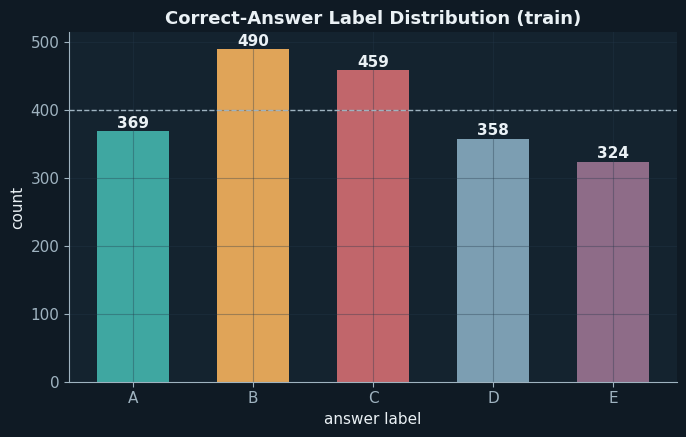

In [37]:
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = train['answer'].value_counts().reindex(OPT_COLS)
bars = ax.bar(counts.index, counts.values, color=PALETTE5, width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 5, str(v), ha='center', color=INK, fontweight='bold')
ax.axhline(counts.mean(), color=MUTE, ls='--', lw=1)
ax.set_title("Correct-Answer Label Distribution (train)")
ax.set_ylabel("count"); ax.set_xlabel("answer label")
plt.tight_layout(); plt.show()

In [38]:
# Interactive version
fig = px.bar(counts, x=counts.index, y=counts.values, color=counts.index,
             color_discrete_sequence=PALETTE5, template=PLOTLY_TEMPLATE,
             labels={'x': 'answer label', 'y': 'count'}, title="Correct-Answer Label Distribution (train)")
fig.update_layout(showlegend=False, height=420)
fig.show()

## 6. Text-length structure

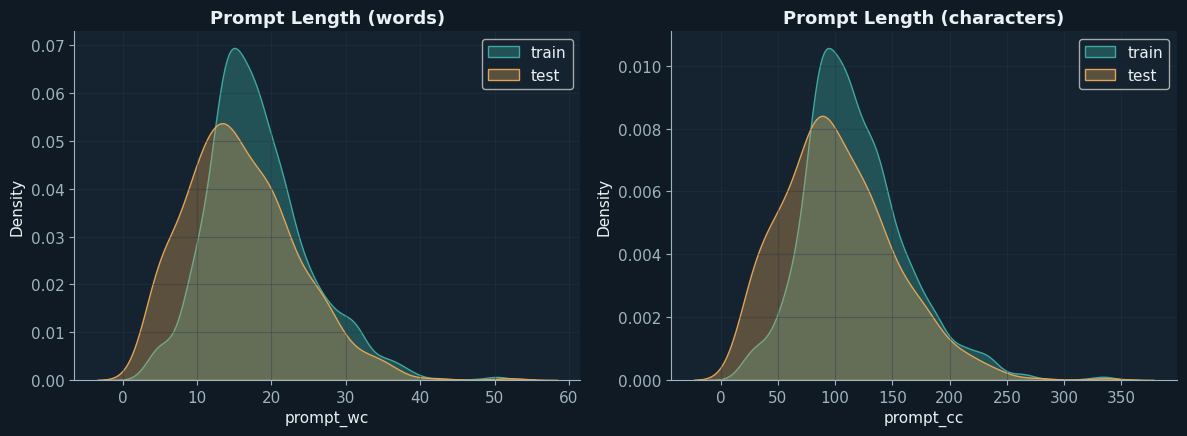

Train prompt words: mean=18.1  median=17
Test  prompt words: mean=15.9  median=15


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.kdeplot(train['prompt_wc'], ax=axes[0], color=ACCENT1, fill=True, alpha=0.35, label='train')
sns.kdeplot(test['prompt_wc'], ax=axes[0], color=ACCENT2, fill=True, alpha=0.35, label='test')
axes[0].set_title("Prompt Length (words)"); axes[0].legend()

sns.kdeplot(train['prompt_cc'], ax=axes[1], color=ACCENT1, fill=True, alpha=0.35, label='train')
sns.kdeplot(test['prompt_cc'], ax=axes[1], color=ACCENT2, fill=True, alpha=0.35, label='test')
axes[1].set_title("Prompt Length (characters)"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Train prompt words: mean=%.1f  median=%.0f" % (train['prompt_wc'].mean(), train['prompt_wc'].median()))
print("Test  prompt words: mean=%.1f  median=%.0f" % (test['prompt_wc'].mean(), test['prompt_wc'].median()))

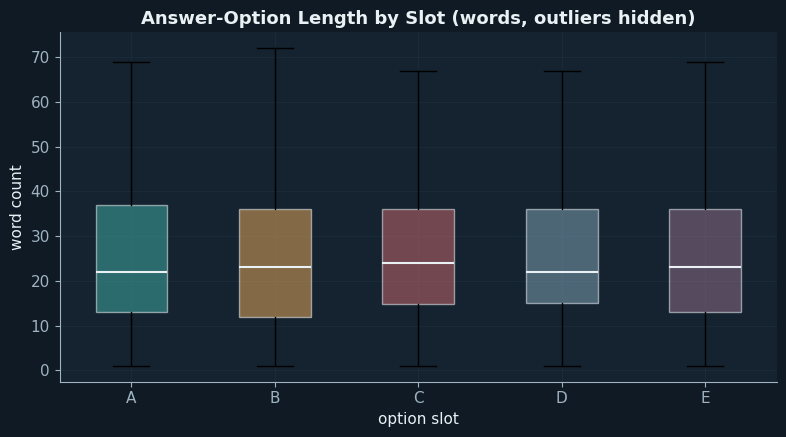

In [40]:
fig, ax = plt.subplots(figsize=(8, 4.5))
data = [train[f'{c}_wc'] for c in OPT_COLS]
bp = ax.boxplot(data, tick_labels=OPT_COLS, patch_artist=True, showfliers=False, widths=0.5)
for patch, color in zip(bp['boxes'], PALETTE5):
    patch.set_facecolor(color); patch.set_alpha(0.55); patch.set_edgecolor(INK)
for med in bp['medians']:
    med.set_color(INK); med.set_linewidth(1.5)
ax.set_title("Answer-Option Length by Slot (words, outliers hidden)")
ax.set_ylabel("word count"); ax.set_xlabel("option slot")
plt.tight_layout(); plt.show()

## 7. Instruction-stem phrasing (train vs test)

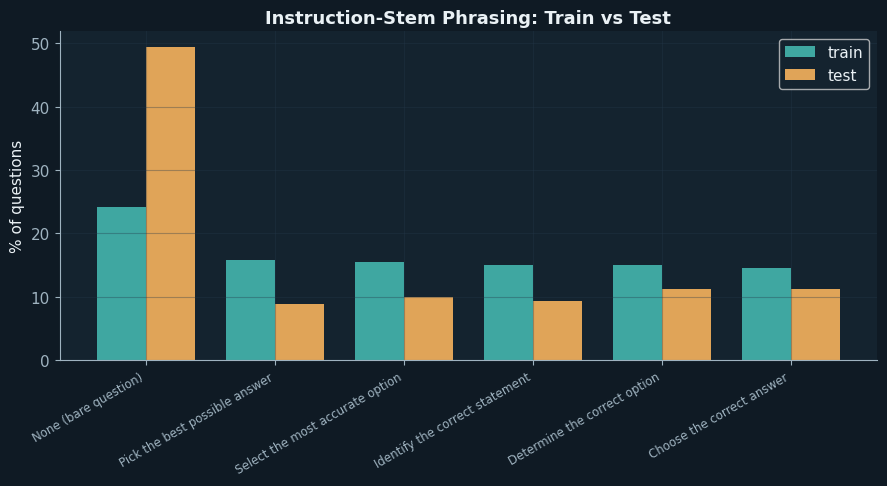

Share with a recognizable instruction stem — train: 75.9%, test: 50.6%


In [41]:
tr_stem = train['stem'].value_counts(normalize=True) * 100
te_stem = test['stem'].value_counts(normalize=True) * 100
all_stems = sorted(set(tr_stem.index) | set(te_stem.index), key=lambda x: -tr_stem.get(x, 0))
x = np.arange(len(all_stems)); w = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, [tr_stem.get(s, 0) for s in all_stems], width=w, color=ACCENT1, label='train')
ax.bar(x + w/2, [te_stem.get(s, 0) for s in all_stems], width=w, color=ACCENT2, label='test')
ax.set_xticks(x); ax.set_xticklabels(all_stems, rotation=30, ha='right', fontsize=8.5)
ax.set_ylabel("% of questions"); ax.set_title("Instruction-Stem Phrasing: Train vs Test")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Share with a recognizable instruction stem — train: {train['has_instruction_stem'].mean():.1%}, "
      f"test: {test['has_instruction_stem'].mean():.1%}")

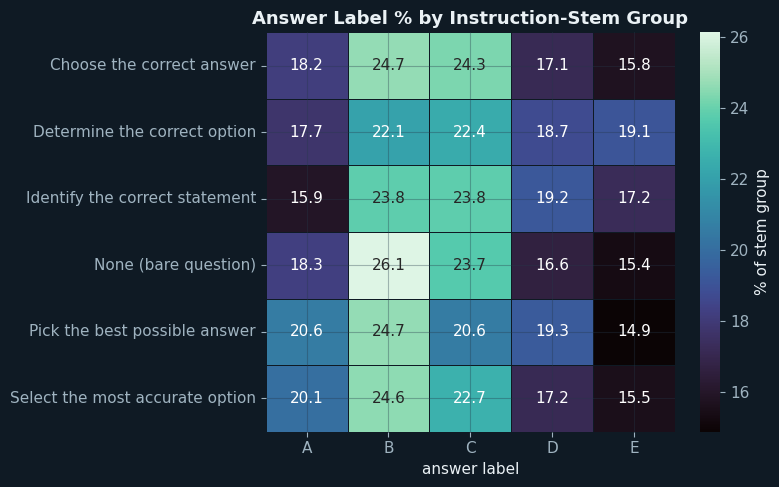

In [42]:
pivot = pd.crosstab(train['stem'], train['answer'], normalize='index') * 100
pivot = pivot.reindex(OPT_COLS, axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='mako', ax=ax,
            cbar_kws={'label': '% of stem group'}, linewidths=0.5, linecolor=BG)
ax.set_title("Answer Label % by Instruction-Stem Group")
ax.set_ylabel(""); ax.set_xlabel("answer label")
plt.tight_layout(); plt.show()

## 8. Positional / length bias check

A classic MCQ-writing artifact: is the correct answer disproportionately the **longest** (most
thorough) option?

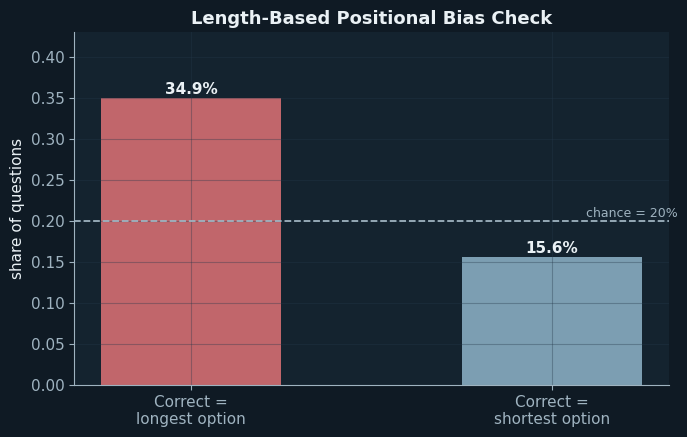

Correct answer is the LONGEST option 34.9% of the time (chance = 20%)
Correct answer is the SHORTEST option 15.6% of the time (chance = 20%)


In [43]:
exp_rate = 1/5
rates = {
    'Correct =\nlongest option': train['is_correct_longest'].mean(),
    'Correct =\nshortest option': train['is_correct_shortest'].mean(),
}
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(list(rates.keys()), list(rates.values()), color=[ACCENT3, ACCENT4], width=0.5)
ax.axhline(exp_rate, color=MUTE, ls='--', lw=1.3)
ax.text(1.35, exp_rate + 0.005, f'chance = {exp_rate:.0%}', color=MUTE, fontsize=9, ha='right')
for b, v in zip(bars, rates.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.1%}', ha='center', color=INK, fontweight='bold')
ax.set_ylabel("share of questions"); ax.set_title("Length-Based Positional Bias Check")
ax.set_ylim(0, max(rates.values()) + 0.08)
plt.tight_layout(); plt.show()

print(f"Correct answer is the LONGEST option {train['is_correct_longest'].mean():.1%} of the time "
      f"(chance = {exp_rate:.0%})")
print(f"Correct answer is the SHORTEST option {train['is_correct_shortest'].mean():.1%} of the time "
      f"(chance = {exp_rate:.0%})")

## 9. Vocabulary & topic mix

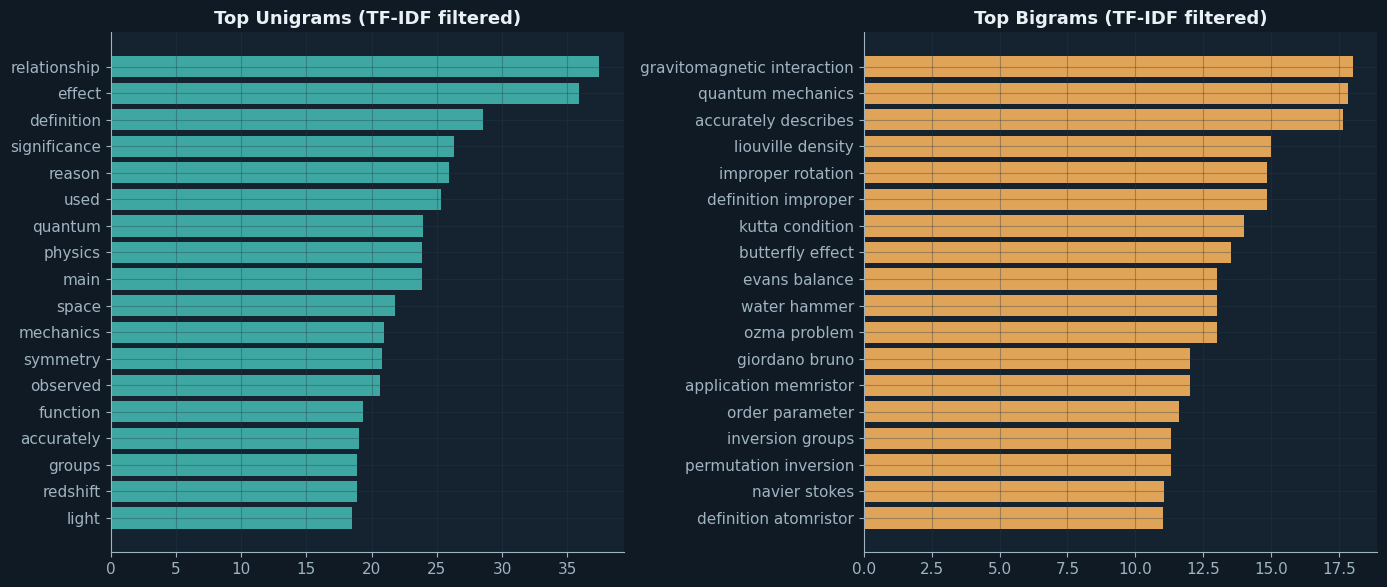

In [44]:
instr_stop = ['correct','following','answer','option','options','based','listed','context','given',
              'choices','carefully','possible','accurate','determine','pick','best','select','identify',
              'statement','choose','statements','among']

def top_ngrams(series, n=1, k=20, extra_stop=None):
    stop = set(ENGLISH_STOP_WORDS)
    if extra_stop: stop |= set(extra_stop)
    vec = TfidfVectorizer(ngram_range=(n, n), stop_words=list(stop), min_df=3, max_features=5000)
    X = vec.fit_transform(series.astype(str))
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    order = np.argsort(freqs)[::-1][:k]
    return [(vocab[i], freqs[i]) for i in order]

uni = top_ngrams(train['prompt'], 1, 18, instr_stop)
bi  = top_ngrams(train['prompt'], 2, 18, instr_stop)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
w1, f1 = zip(*sorted(uni, key=lambda x: x[1]))
axes[0].barh(w1, f1, color=ACCENT1); axes[0].set_title("Top Unigrams (TF-IDF filtered)")
w2, f2 = zip(*sorted(bi, key=lambda x: x[1]))
axes[1].barh(w2, f2, color=ACCENT2); axes[1].set_title("Top Bigrams (TF-IDF filtered)")
plt.tight_layout(); plt.show()

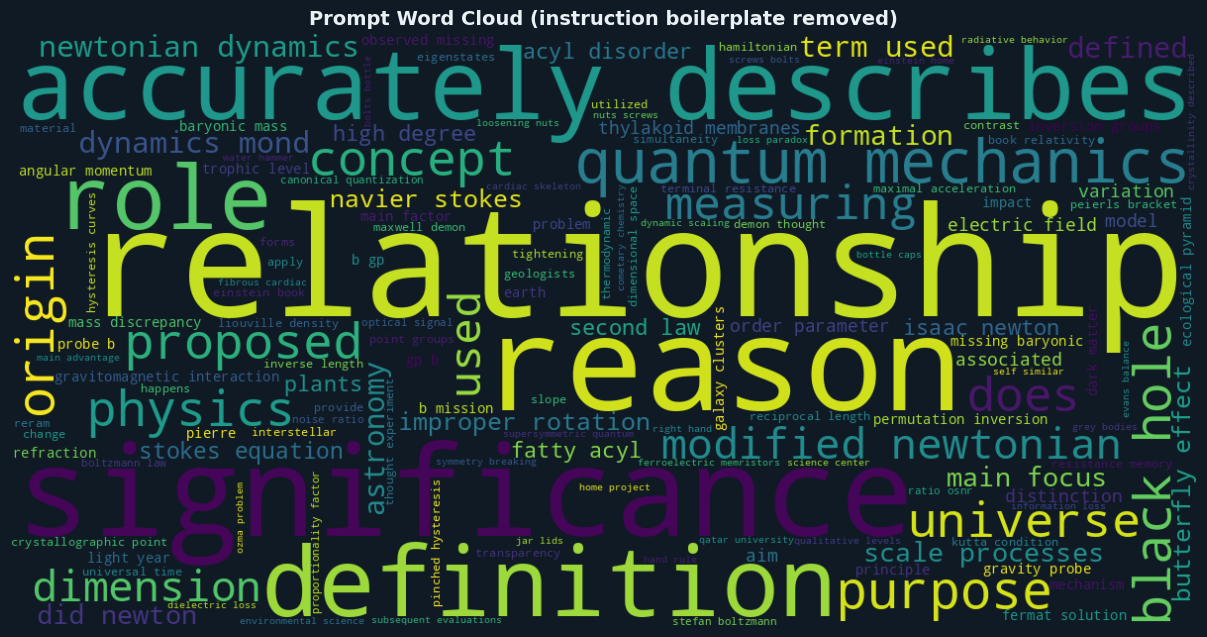

In [45]:
# Word cloud of prompt content (instruction boilerplate removed)
stop_wc = set(ENGLISH_STOP_WORDS) | set(instr_stop)
text_blob = ' '.join(train['prompt'].astype(str)).lower()
wc = WordCloud(width=1200, height=600, background_color=BG, colormap='viridis',
               stopwords=stop_wc, max_words=150).generate(text_blob)

plt.figure(figsize=(13, 6.5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Prompt Word Cloud (instruction boilerplate removed)", color=INK, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

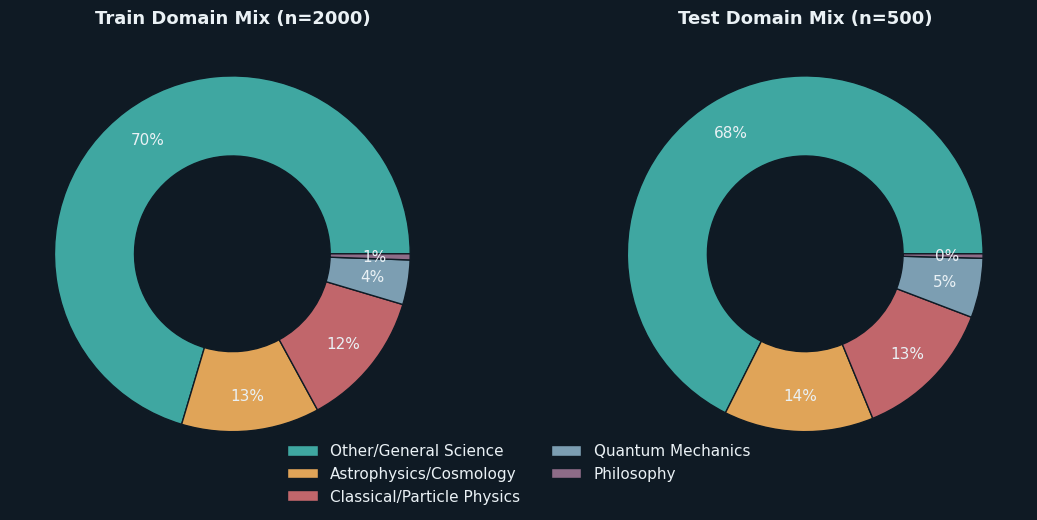

Train domain counts:
 domain
Other/General Science         1408
Classical/Particle Physics     251
Astrophysics/Cosmology         249
Quantum Mechanics               81
Philosophy                      11
Name: count, dtype: int64

Test domain counts:
 domain
Other/General Science         338
Astrophysics/Cosmology         68
Classical/Particle Physics     65
Quantum Mechanics              27
Philosophy                      2
Name: count, dtype: int64


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df, title in zip(axes, [train, test], ['Train', 'Test']):
    vc = df['domain'].value_counts()
    ax.pie(vc.values, autopct='%1.0f%%', pctdistance=0.8, colors=PALETTE5,
           wedgeprops=dict(width=0.45, edgecolor=BG))
    ax.set_title(f"{title} Domain Mix (n={len(df)})")
fig.legend(vc.index, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), frameon=False)
plt.tight_layout(); plt.show()

print("Train domain counts:\n", train['domain'].value_counts())
print("\nTest domain counts:\n", test['domain'].value_counts())

## 10. Correlation structure of length features

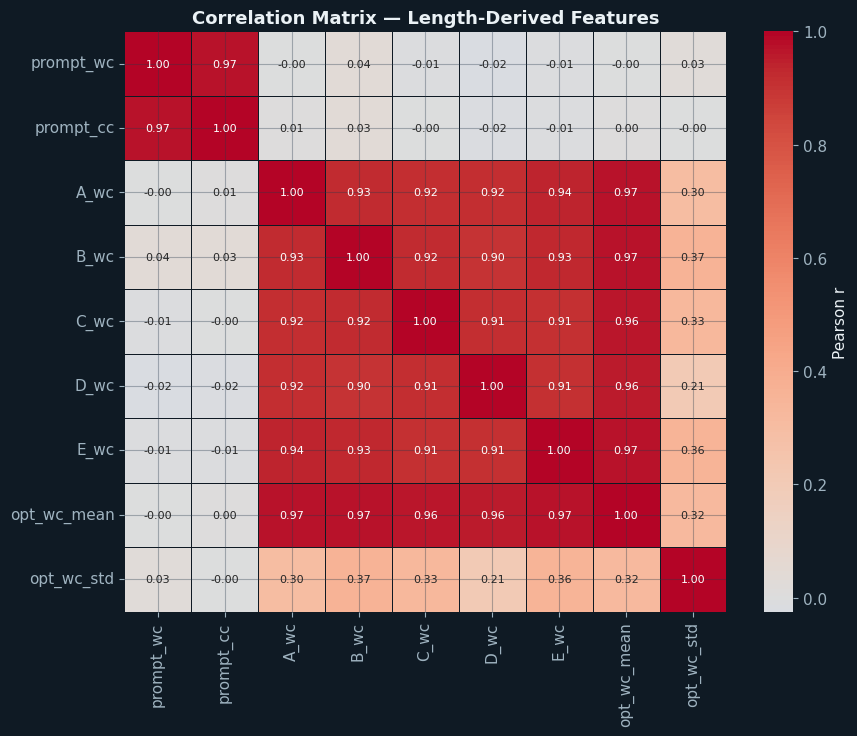

In [47]:
feat_cols = ['prompt_wc', 'prompt_cc'] + [f'{c}_wc' for c in OPT_COLS] + ['opt_wc_mean', 'opt_wc_std']
corr = train[feat_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, linecolor=BG, cbar_kws={'label': 'Pearson r'}, annot_kws={'size': 8})
ax.set_title("Correlation Matrix — Length-Derived Features")
plt.tight_layout(); plt.show()

## 11. Duplicate / paraphrase groups

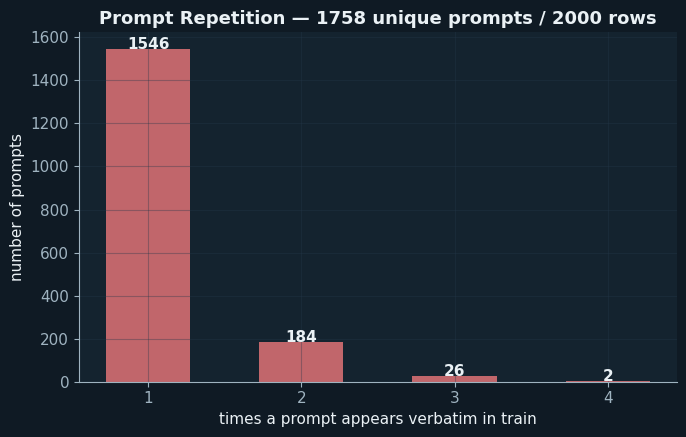

Paraphrase groups: 212
Answer-label consistency within paraphrase groups: 100.0%


In [48]:
dup_sizes = train.groupby('prompt')['id'].count()
dist = dup_sizes.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(dist.index.astype(str), dist.values, color=ACCENT3, width=0.55)
for b, v in zip(bars, dist.values):
    ax.text(b.get_x() + b.get_width()/2, v + 2, str(v), ha='center', color=INK, fontweight='bold')
ax.set_title(f"Prompt Repetition — {len(dup_sizes)} unique prompts / {len(train)} rows")
ax.set_xlabel("times a prompt appears verbatim in train"); ax.set_ylabel("number of prompts")
plt.tight_layout(); plt.show()

# Are paraphrases of the same question always labeled the same answer?
same_q = train[train['prompt'].duplicated(keep=False)].sort_values('prompt')
consistency = same_q.groupby('prompt')['answer'].nunique()
print(f"Paraphrase groups: {(dup_sizes > 1).sum()}")
print(f"Answer-label consistency within paraphrase groups: {(consistency == 1).mean():.1%}")

## 12. TF-IDF embedding of prompts

Used as the base representation for the 3D visualizations and clustering below.

In [49]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english', min_df=2, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train['prompt'])
X_test = tfidf.transform(test['prompt'])
print("TF-IDF matrix shape (train):", X_train.shape)

TF-IDF matrix shape (train): (2000, 2488)


## 13. 3D visualization — PCA of prompt semantics

Interactive: drag to rotate, scroll to zoom, hover for details.

In [50]:
pca = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(X_train.toarray())
train['pc1'], train['pc2'], train['pc3'] = coords[:, 0], coords[:, 1], coords[:, 2]

fig = px.scatter_3d(
    train, x='pc1', y='pc2', z='pc3', color='answer',
    color_discrete_sequence=PALETTE5, template=PLOTLY_TEMPLATE, opacity=0.75,
    hover_data={'prompt': True, 'pc1': False, 'pc2': False, 'pc3': False},
    title="3D PCA of Prompt TF-IDF Space — colored by correct-answer label<br>"
          "<sup>No separation by label — the label isn't predictable from prompt text alone</sup>"
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=650, scene=dict(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
    zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]:.1%})"))
fig.show()

In [51]:
fig = px.scatter_3d(
    train, x='pc1', y='pc2', z='pc3', color='domain',
    color_discrete_sequence=PALETTE5, template=PLOTLY_TEMPLATE, opacity=0.8,
    hover_data={'prompt': True, 'pc1': False, 'pc2': False, 'pc3': False},
    title="3D PCA of Prompt TF-IDF Space — colored by keyword-tagged domain<br>"
          "<sup>Clear topical clustering — content drives geometry, not the answer label</sup>"
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=650, scene=dict(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
    zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]:.1%})"))
fig.show()

## 14. 3D visualization — t-SNE of prompt semantics (train vs test)

In [52]:
combo = pd.concat([
    train[['prompt', 'domain']].assign(split='train'),
    test[['prompt', 'domain']].assign(split='test')
], ignore_index=True)

tfidf2 = TfidfVectorizer(max_features=2500, stop_words='english', min_df=2, ngram_range=(1, 2))
X_combo = tfidf2.fit_transform(combo['prompt'])
X_svd = TruncatedSVD(n_components=50, random_state=42).fit_transform(X_combo)

tsne = TSNE(n_components=3, random_state=42, perplexity=35, init='pca', learning_rate='auto')
emb = tsne.fit_transform(X_svd)
combo['t1'], combo['t2'], combo['t3'] = emb[:, 0], emb[:, 1], emb[:, 2]

fig = px.scatter_3d(
    combo, x='t1', y='t2', z='t3', color='split',
    color_discrete_map={'train': ACCENT1, 'test': ACCENT3}, template=PLOTLY_TEMPLATE, opacity=0.6,
    hover_data={'prompt': True, 't1': False, 't2': False, 't3': False},
    title="3D t-SNE of Prompt Semantics — Train vs Test<br>"
          "<sup>Overlapping clouds → test covers the same topic space as train</sup>"
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=650)
fig.show()

In [53]:
fig = px.scatter_3d(
    combo, x='t1', y='t2', z='t3', color='domain',
    color_discrete_sequence=PALETTE5, template=PLOTLY_TEMPLATE, opacity=0.7,
    hover_data={'prompt': True, 't1': False, 't2': False, 't3': False},
    title="3D t-SNE of Prompt Semantics — colored by domain (train+test combined)"
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=650)
fig.show()

## 15. 3D visualization — pure numeric length features

In [54]:
fig = px.scatter_3d(
    train, x='prompt_wc', y='opt_wc_mean', z='opt_wc_std', color='answer',
    color_discrete_sequence=PALETTE5, template=PLOTLY_TEMPLATE, opacity=0.75,
    labels={'prompt_wc': 'prompt word count', 'opt_wc_mean': 'mean option word count',
            'opt_wc_std': 'option word-count std'},
    title="3D Feature Space: Prompt Length × Option Length × Option Length Spread<br>"
          "<sup>Colored by correct-answer label — length bias is real but partial, not a standalone classifier</sup>"
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=650)
fig.show()

## 16. Unsupervised clustering — K-means (k=6) on prompt semantics

Sanity-checks the hand-built domain tagger using no keyword rules at all.

In [55]:
svd3 = TruncatedSVD(n_components=3, random_state=42).fit_transform(
    TfidfVectorizer(max_features=3000, stop_words='english', min_df=2).fit_transform(train['prompt'])
)
km = KMeans(n_clusters=6, random_state=42, n_init=10)
train['cluster'] = km.fit_predict(svd3).astype(str)
train['svd1'], train['svd2'], train['svd3'] = svd3[:, 0], svd3[:, 1], svd3[:, 2]

fig = px.scatter_3d(
    train, x='svd1', y='svd2', z='svd3', color='cluster',
    color_discrete_sequence=PALETTE5 + ['#5C7A99'], template=PLOTLY_TEMPLATE, opacity=0.75,
    hover_data={'prompt': True, 'domain': True, 'svd1': False, 'svd2': False, 'svd3': False},
    title="Unsupervised K-Means (k=6) on Prompt TF-IDF/SVD Space<br>"
          "<sup>Hover to compare cluster assignment against the keyword-tagged domain</sup>"
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=650)
fig.show()

# Cross-tab: does the unsupervised cluster line up with the keyword-based domain?
pd.crosstab(train['cluster'], train['domain'])

domain,Astrophysics/Cosmology,Classical/Particle Physics,Other/General Science,Philosophy,Quantum Mechanics
cluster,,,,,
0,44,35,251,1,13
1,35,35,177,2,8
2,34,37,228,1,10
3,64,75,303,2,23
4,9,6,39,0,5
5,63,63,410,5,22


## 17. Modeling takeaways for the MAP@3 task

- **Baseline** — Predicting `B C A` for every row beats random guessing, given the 24.5% / 23.0% /
  18.4% label prior. Use as a floor to beat.
- **Feature** — Option length (especially "is this the longest option?") is a cheap, informative
  re-ranking signal — correct answer is the longest option **35%** of the time vs 20% chance.
  Combine with a semantic model rather than relying on it alone.
- **Leakage** — Group any CV split by paraphrase groups (same underlying question, different
  instruction-stem wording). Labels are 100% consistent within a group, so leaking a paraphrase
  across train/val inflates validation scores.
- **Robustness** — Only ~51% of test prompts carry a recognizable instruction stem vs ~76% of
  train. Don't let a model lean on stem wording — it should perform on bare questions too.
- **Architecture** — Prompt geometry clusters cleanly by topic (physics / astro / QM / philosophy)
  but *not* by answer label. The task genuinely requires prompt↔option semantic matching per
  question — favor cross-encoder-style scoring of (prompt, option) pairs over a prompt-only
  embedding/classifier.
